# ⭐ Day 13: Pandas Indexing, Selection & Filtering
Master Precise Data Access for AI & ML | Step-by-Step Tutorial with Examples & Exercises

**Day 13 of 369-day Python & AI Learning Path** 💡

## Introduction

Welcome to Day 13 of your Python & AI journey! Today we dive deep into one of the most critical skills in data science: **precise data access**. Whether you're building neural networks, training decision trees, or preprocessing data for deep learning, the ability to select exactly the right rows and columns is fundamental.

In AI/ML workflows, indexing and selection serve multiple crucial purposes. **Feature selection** allows you to choose specific columns that will feed into your models, while **row filtering** helps you create clean training and validation datasets. When handling missing data, you'll need to select specific subsets for imputation strategies. During **train/test splits**, conditional filtering ensures your data is properly segmented. Even advanced techniques like **feature subset selection** for ensemble methods rely heavily on these foundational skills.

Mastering `.loc[]` and `.iloc[]` isn't just about syntax—it's about efficiency. Poor indexing choices can slow down your data pipelines by orders of magnitude. Boolean masking and the `query()` method enable readable, maintainable code that other data scientists can easily understand. When you're working with millions of rows, these techniques become performance-critical.

By the end of this tutorial, you'll confidently navigate any dataset, selecting features for ML models, filtering high-quality samples, and preparing clean data matrices that directly impact your model's performance. Let's unlock the power of precise data manipulation! 🚀

## 📌 Table of Contents

1. [Recap: Series and DataFrame Basics](#recap)
2. [Label-Based Indexing with .loc[]](#loc)
3. [Position-Based Indexing with .iloc[]](#iloc)
4. [.loc vs .iloc: Key Differences](#differences)
5. [Boolean Indexing & Masking](#boolean)
6. [Combining Multiple Conditions](#conditions)
7. [Selecting Columns While Filtering](#select-filter)
8. [The query() Method](#query)
9. [Setting and Resetting Index](#index)
10. [MultiIndex (Hierarchical Indexing)](#multiindex)
11. [Practical AI/ML Examples](#practical)
12. [🛠️ Hands-On Exercises](#exercises)
13. [Solutions](#solutions)
14. [What's Next: Day 14](#next)

## 1. Recap: Series and DataFrame Basics {#recap}

Before diving into advanced indexing, let's create a realistic dataset and review basic access patterns. We'll use a synthetic **customer churn dataset**—a common scenario in ML classification tasks.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Create synthetic customer dataset (1000 customers)
n = 1000
data = {
    'customer_id': range(1001, 2001),
    'age': np.random.randint(18, 80, n),
    'gender': np.random.choice(['M', 'F'], n),
    'income': np.random.normal(60000, 20000, n).astype(int),
    'account_tenure_months': np.random.randint(1, 120, n),
    'monthly_spend': np.random.normal(150, 80, n).astype(int),
    'support_tickets': np.random.poisson(2, n),
    'satisfaction_score': np.random.uniform(1, 10, n).round(1),
    'churned': np.random.choice([0, 1], n, p=[0.7, 0.3])  # 30% churn rate
}

df = pd.DataFrame(data)
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn Names:")
print(df.columns.tolist())
print("\nBasic Info:")
print(df.info())

Dataset Shape: (1000, 9)

First 5 rows:
   customer_id  age gender  income  account_tenure_months  monthly_spend  \
0         1001   56      M   67150                     17              0   
1         1002   69      M   48254                     88            230   
2         1003   46      F   56144                     21             95   
3         1004   32      M   56919                     51            213   
4         1005   60      M   87137                     59             -7   

   support_tickets  satisfaction_score  churned  
0                3                 5.5        0  
1                0                 2.4        0  
2                0                 2.6        0  
3                1                 4.3        0  
4                3                 4.9        0  

Column Names:
['customer_id', 'age', 'gender', 'income', 'account_tenure_months', 'monthly_spend', 'support_tickets', 'satisfaction_score', 'churned']

Basic Info:
<class 'pandas.DataFrame'>
RangeIndex:

## 2. Label-Based Indexing with .loc[] {#loc}

The `.loc[]` accessor selects data by **labels** (column names and index values). It's inclusive on both ends and is the preferred method for production ML code because it's explicit and readable.

**Key features of .loc[]:**
- Uses row labels and column names
- Syntax: `df.loc[row_labels, column_labels]`
- Inclusive slicing (both start and end are included)
- Accepts boolean arrays for row selection

In [24]:
# Basic .loc[] usage - select specific rows and columns by name
print("=== .loc[] Examples ===\n")

# Select single row by index label (returns Series)
print("Single customer (index 0):")
print(df.loc[0])
print(f"Type: {type(df.loc[0])}\n")

# Select multiple rows by index labels
print("First 3 customers (rows 0,1,2):")
subset = df.loc[0:2]  # Inclusive - includes row 2!
print(subset)
print(f"Shape: {subset.shape}\n")

# Select specific rows AND specific columns
print("Customers 0-2 with only name, age, income:")
selected = df.loc[0:2, ['customer_id', 'age', 'income']]
print(selected)
print(f"Shape: {selected.shape}\n")

# Select all rows, specific columns
print("All customers, only behavioral features:")
behavioral = df.loc[:, ['monthly_spend', 'support_tickets', 'satisfaction_score']]
print(f"Shape: {behavioral.shape}")
print(behavioral.head())

=== .loc[] Examples ===

Single customer (index 0):
customer_id               1001
age                         56
gender                       M
income                   67150
account_tenure_months       17
monthly_spend                0
support_tickets              3
satisfaction_score         5.5
churned                      0
Name: 0, dtype: object
Type: <class 'pandas.Series'>

First 3 customers (rows 0,1,2):
   customer_id  age gender  income  account_tenure_months  monthly_spend  \
0         1001   56      M   67150                     17              0   
1         1002   69      M   48254                     88            230   
2         1003   46      F   56144                     21             95   

   support_tickets  satisfaction_score  churned  
0                3                 5.5        0  
1                0                 2.4        0  
2                0                 2.6        0  
Shape: (3, 9)

Customers 0-2 with only name, age, income:
   customer_id  age 

## 3. Position-Based Indexing with .iloc[] {#iloc}

The `.iloc[]` accessor selects data by **integer position** (0-based indexing). Think of it like NumPy array indexing. It's exclusive on the end (like Python slicing).

**Key features of .iloc[]:**
- Uses integer positions (0, 1, 2, ...)
- Syntax: `df.iloc[row_positions, column_positions]`
- Exclusive end slicing (like standard Python)
- Useful when column names are long or when iterating by position

In [25]:
# Basic .iloc[] usage - select by position
print("=== .iloc[] Examples ===\n")

# Select first 3 rows (positions 0, 1, 2)
print("First 3 rows by position:")
print(df.iloc[0:3])  # Exclusive end - stops before 3
print(f"Shape: {df.iloc[0:3].shape}\n")

# Select rows 10-15 (positions 10,11,12,13,14)
print("Rows 10-14 (5 rows):")
print(df.iloc[10:15])
print(f"Shape: {df.iloc[10:15].shape}\n")

# Select specific rows and specific column positions
print("Rows 0-2, columns 0,1,2 (positions):")
print(df.iloc[0:3, 0:3])
print(f"Shape: {df.iloc[0:3, 0:3].shape}\n")

# Select last 3 rows using negative indexing
print("Last 3 customers:")
print(df.iloc[-3:])
print(f"Shape: {df.iloc[-3:].shape}")

=== .iloc[] Examples ===

First 3 rows by position:
   customer_id  age gender  income  account_tenure_months  monthly_spend  \
0         1001   56      M   67150                     17              0   
1         1002   69      M   48254                     88            230   
2         1003   46      F   56144                     21             95   

   support_tickets  satisfaction_score  churned  
0                3                 5.5        0  
1                0                 2.4        0  
2                0                 2.6        0  
Shape: (3, 9)

Rows 10-14 (5 rows):
    customer_id  age gender  income  account_tenure_months  monthly_spend  \
10         1011   36      M   78045                     64            117   
11         1012   40      F   19761                     11            204   
12         1013   28      M   80377                    110            158   
13         1014   28      M   58997                     19            196   
14         1015   41  

## 4. .loc vs .iloc: Key Differences {#differences}

Understanding when to use each is crucial. Here's a clear comparison with visual examples:

In [26]:
# Clear comparison of .loc vs .iloc
print("=== .loc vs .iloc Comparison ===\n")

# Create a small example dataframe with custom index
sample = pd.DataFrame({
    'A': [1, 2, 3, 4, 5],
    'B': ['a', 'b', 'c', 'd', 'e']
}, index=[10, 20, 30, 40, 50])  # Custom index labels

print("Sample DataFrame:")
print(sample)
print(f"Index: {sample.index.tolist()}\n")

# .loc uses LABELS
print(".loc[10:30] selects rows with labels 10, 20, 30:")
print(sample.loc[10:30])
print()

# .iloc uses POSITIONS
print(".iloc[0:2] selects rows at positions 0, 1 (exclusive end):")
print(sample.iloc[0:2])
print()

# Common pitfall: using .loc with integers when index is RangeIndex
print("On our customer df (RangeIndex 0-999):")
print("df.loc[0:2] gives rows with labels 0, 1, 2 (3 rows)")
print(f"Result shape: {df.loc[0:2].shape}")
print("df.iloc[0:2] gives rows at positions 0, 1 (2 rows)")
print(f"Result shape: {df.iloc[0:2].shape}")

=== .loc vs .iloc Comparison ===

Sample DataFrame:
    A  B
10  1  a
20  2  b
30  3  c
40  4  d
50  5  e
Index: [10, 20, 30, 40, 50]

.loc[10:30] selects rows with labels 10, 20, 30:
    A  B
10  1  a
20  2  b
30  3  c

.iloc[0:2] selects rows at positions 0, 1 (exclusive end):
    A  B
10  1  a
20  2  b

On our customer df (RangeIndex 0-999):
df.loc[0:2] gives rows with labels 0, 1, 2 (3 rows)
Result shape: (3, 9)
df.iloc[0:2] gives rows at positions 0, 1 (2 rows)
Result shape: (2, 9)


## 5. Boolean Indexing & Masking {#boolean}

Boolean indexing (masking) is the most powerful filtering technique in Pandas. It allows you to select rows based on conditions, which is essential for preparing ML datasets.

**How it works:**
1. Create a boolean condition (e.g., `df['age'] > 30`)
2. Pass it to `.loc[]` or use directly in `[]`
3. Returns only rows where condition is True

In [27]:
# Boolean masking examples
print("=== Boolean Indexing Examples ===\n")

# Single condition: High-income customers
high_income = df['income'] > 80000
print(f"Customers with income > $80k: {high_income.sum()} out of {len(df)}")
high_income_df = df.loc[high_income]
print(f"Filtered shape: {high_income_df.shape}")
print(f"Average age of high-income customers: {high_income_df['age'].mean():.1f}\n")

# Direct boolean indexing (shorthand for .loc)
churned_customers = df[df['churned'] == 1]
print(f"Churned customers: {len(churned_customers)} ({len(churned_customers)/len(df)*100:.1f}%)")
print(f"Churned avg satisfaction: {churned_customers['satisfaction_score'].mean():.2f}")
print(f"Retained avg satisfaction: {df[df['churned']==0]['satisfaction_score'].mean():.2f}\n")

# Multiple conditions with comparison operators
# Note: Use & for AND, | for OR, ~ for NOT (not 'and', 'or', 'not')
vip_customers = df.loc[(df['income'] > 70000) & (df['satisfaction_score'] > 8)]
print(f"VIP customers (high income + high satisfaction): {len(vip_customers)}")
print(f"VIP churn rate: {vip_customers['churned'].mean()*100:.1f}%")

=== Boolean Indexing Examples ===

Customers with income > $80k: 159 out of 1000
Filtered shape: (159, 9)
Average age of high-income customers: 49.9

Churned customers: 262 (26.2%)
Churned avg satisfaction: 5.13
Retained avg satisfaction: 5.42

VIP customers (high income + high satisfaction): 62
VIP churn rate: 22.6%


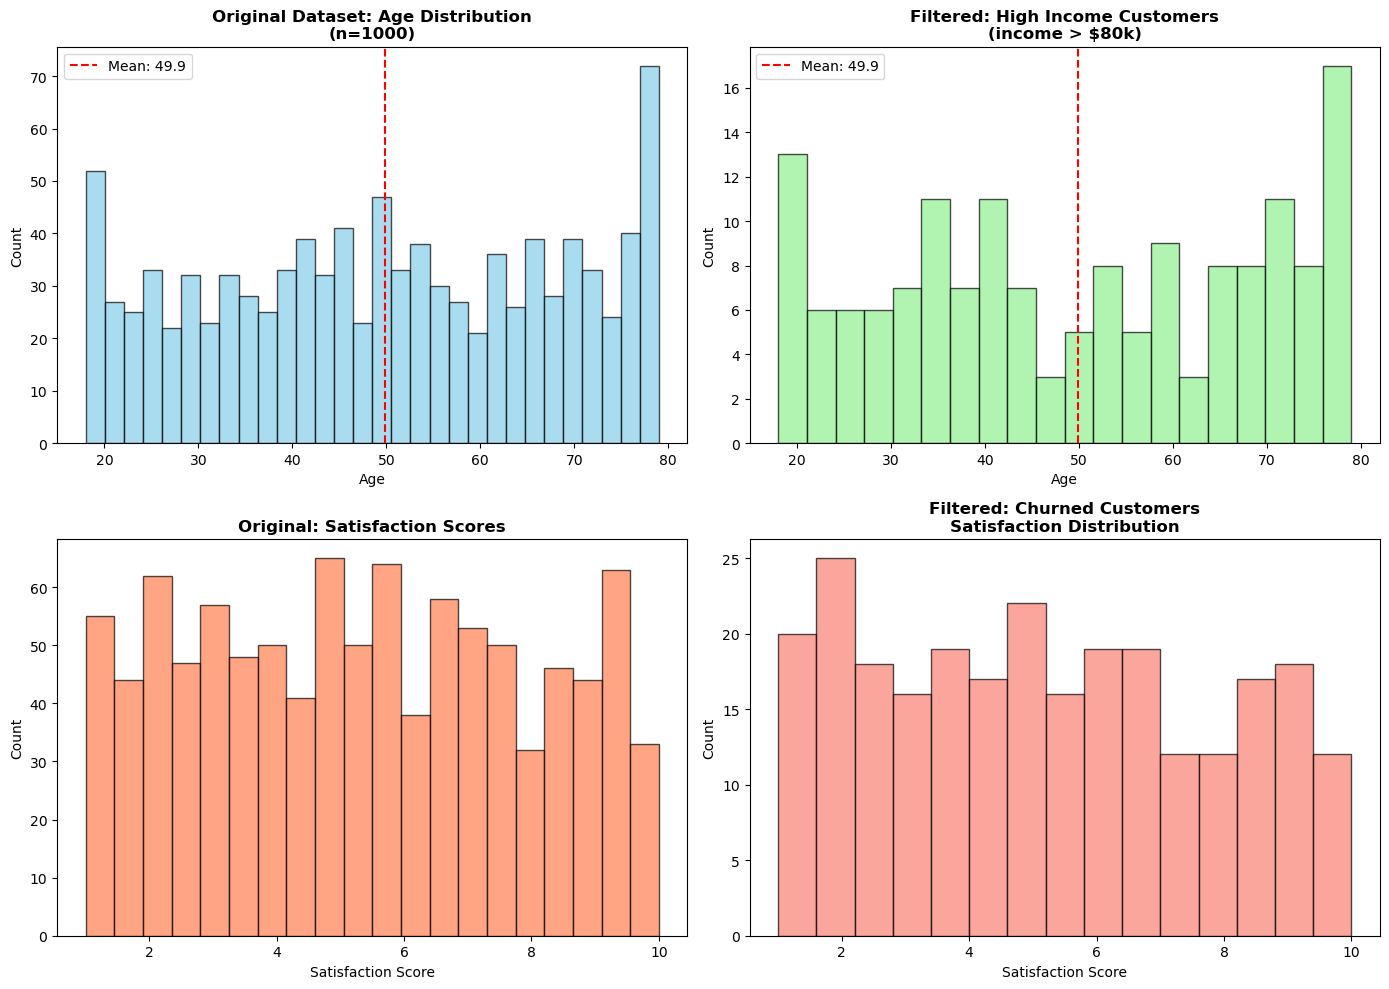


✅ Saved distribution comparison plot


In [28]:
# Visualization: Distribution before and after filtering
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original age distribution
axes[0, 0].hist(df['age'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Original Dataset: Age Distribution\n(n=1000)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Count')
axes[0, 0].axvline(df['age'].mean(), color='red', linestyle='--', label=f'Mean: {df["age"].mean():.1f}')
axes[0, 0].legend()

# Filtered: High income age distribution
axes[0, 1].hist(high_income_df['age'], bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Filtered: High Income Customers\n(income > $80k)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Count')
axes[0, 1].axvline(high_income_df['age'].mean(), color='red', linestyle='--', label=f'Mean: {high_income_df["age"].mean():.1f}')
axes[0, 1].legend()

# Original satisfaction distribution
axes[1, 0].hist(df['satisfaction_score'], bins=20, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Original: Satisfaction Scores', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Satisfaction Score')
axes[1, 0].set_ylabel('Count')

# Filtered: Churned customers satisfaction
axes[1, 1].hist(churned_customers['satisfaction_score'], bins=15, color='salmon', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Filtered: Churned Customers\nSatisfaction Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Satisfaction Score')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()
print("\n✅ Saved distribution comparison plot")

## 6. Combining Multiple Conditions {#conditions}

Real-world ML preprocessing requires combining multiple criteria. Use parentheses around each condition and the bitwise operators `&` (AND), `|` (OR), and `~` (NOT).

**Important:** You cannot use Python's `and`, `or`, `not` keywords with Pandas Series. You must use `&`, `|`, `~`.

In [29]:
# Complex boolean conditions
print("=== Combining Multiple Conditions ===\n")

# Condition 1: At-risk customers (high tickets OR low satisfaction) AND high value
condition = ((df['support_tickets'] > 3) | (df['satisfaction_score'] < 4)) & (df['monthly_spend'] > 200)
at_risk = df.loc[condition]
print(f"At-risk high-value customers: {len(at_risk)}")
print(f"At-risk churn rate: {at_risk['churned'].mean()*100:.1f}%")
print(f"Overall churn rate: {df['churned'].mean()*100:.1f}%\n")

# Condition 2: Young high-spenders (demographic segment)
young_high_spenders = df.loc[(df['age'] < 30) & (df['monthly_spend'] > 180)]
print(f"Young high-spenders (<30, spend >$180): {len(young_high_spenders)}")
print(f"Gender distribution:\n{young_high_spenders['gender'].value_counts()}\n")

# Condition 3: NOT churned AND long tenure (loyal customers)
loyal = df.loc[(~df['churned'].astype(bool)) & (df['account_tenure_months'] > 60)]
print(f"Loyal long-term customers: {len(loyal)}")
print(f"Average tenure: {loyal['account_tenure_months'].mean():.1f} months")

# Using isin() for multiple OR conditions on categorical data
target_genders = df.loc[df['gender'].isin(['F'])]
print(f"\nFemale customers: {len(target_genders)} ({len(target_genders)/len(df)*100:.1f}%)")

=== Combining Multiple Conditions ===

At-risk high-value customers: 120
At-risk churn rate: 36.7%
Overall churn rate: 26.2%

Young high-spenders (<30, spend >$180): 56
Gender distribution:
gender
F    30
M    26
Name: count, dtype: int64

Loyal long-term customers: 349
Average tenure: 90.5 months

Female customers: 477 (47.7%)


## 7. Selecting Columns While Filtering {#select-filter}

A common ML pattern: filter rows based on conditions, then select only the features you need for modeling. This creates clean X (features) and y (target) matrices.

In [30]:
# Filter rows AND select specific columns simultaneously
print("=== Filtering + Column Selection ===\n")

# ML Pattern 1: Select features and target for modeling
# Get only numerical features for customers with complete data
numerical_features = ['age', 'income', 'account_tenure_months', 'monthly_spend', 'support_tickets', 'satisfaction_score']
X = df.loc[df['churned'].notna(), numerical_features]  # Features
y = df.loc[df['churned'].notna(), 'churned']          # Target
print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")
print(f"Features: {X.columns.tolist()}\n")

# ML Pattern 2: Training set - specific segment
train_segment = df.loc[
    (df['account_tenure_months'] < 24),  # New customers
    ['age', 'income', 'monthly_spend', 'satisfaction_score', 'churned']
]
print(f"New customers training set shape: {train_segment.shape}")
print(train_segment.head())
print()

# ML Pattern 3: Exclude ID columns for analysis
analysis_cols = [col for col in df.columns if col != 'customer_id']
analysis_data = df.loc[df['income'] > 50000, analysis_cols]
print(f"Analysis data (no IDs, income >50k): {analysis_data.shape}")

=== Filtering + Column Selection ===

Feature matrix X shape: (1000, 6)
Target vector y shape: (1000,)
Features: ['age', 'income', 'account_tenure_months', 'monthly_spend', 'support_tickets', 'satisfaction_score']

New customers training set shape: (186, 5)
    age  income  monthly_spend  satisfaction_score  churned
0    56   67150              0                 5.5        0
2    46   56144             95                 2.6        0
9    75   85948             73                 6.2        0
11   40   19761            204                 6.0        0
13   28   58997            196                 4.0        0

Analysis data (no IDs, income >50k): (685, 8)


## 8. The query() Method {#query}

The `query()` method provides a more readable, SQL-like syntax for filtering. It's especially useful for complex conditions and when working interactively.

**Benefits:**
- More readable for complex queries
- No need for excessive parentheses
- String-based expressions feel like SQL
- Often faster for very large DataFrames

In [31]:
# Using query() for readable filtering
print("=== query() Method Examples ===\n")

# Simple query
high_earners = df.query('income > 80000')
print(f"High earners via query(): {len(high_earners)}")

# Query with multiple conditions (more readable than & |)
prime_customers = df.query('age > 25 and age < 50 and monthly_spend > 150')
print(f"Prime customers (25-50 years, high spend): {len(prime_customers)}")

# Query with OR conditions
needs_attention = df.query('support_tickets > 4 or satisfaction_score < 3')
print(f"Customers needing attention: {len(needs_attention)}")
print(f"Their churn rate: {needs_attention['churned'].mean()*100:.1f}%\n")

# Query with external variables using @
min_income_threshold = 60000
max_age_limit = 40
target_group = df.query('income > @min_income_threshold and age < @max_age_limit')
print(f"Target group (income>${min_income_threshold}, age<{max_age_limit}): {len(target_group)}")

# Query with column arithmetic
spend_ratio = df.query('monthly_spend / income * 100 > 0.3')  # Spend > 0.3% of income
print(f"High spend ratio customers: {len(spend_ratio)}")

=== query() Method Examples ===

High earners via query(): 159
Prime customers (25-50 years, high spend): 174
Customers needing attention: 261
Their churn rate: 30.7%

Target group (income>$60000, age<40): 155
High spend ratio customers: 391


## 9. Setting and Resetting Index {#index}

Custom indexes make data selection more intuitive. Customer IDs, dates, or categories often make better indexes than default integers.

**Common operations:**
- `set_index()`: Make a column the index
- `reset_index()`: Convert index back to column (default 0,1,2...)
- `reset_index(drop=True)`: Reset without keeping old index as column

In [32]:
# Index manipulation
print("=== Setting and Resetting Index ===\n")

# Set customer_id as index (makes more sense for lookups)
df_indexed = df.set_index('customer_id')
print("After set_index('customer_id'):")
print(f"Index: {df_indexed.index[:5].tolist()}...")
print(f"Columns: {df_indexed.columns.tolist()}\n")

# Now use .loc with meaningful IDs
print("Select customer 1001:")
print(df_indexed.loc[1001])
print()

print("Select customers 1001-1005:")
print(df_indexed.loc[1001:1005])
print()

# Select multiple specific customers
selected_ids = [1001, 1050, 1100, 1500]
print(f"Select customers {selected_ids}:")
print(df_indexed.loc[selected_ids, ['age', 'income', 'churned']])
print()

# Reset index back to default
df_reset = df_indexed.reset_index()
print(f"After reset_index(): {df_reset.shape}")
print(f"Columns now include customer_id: {'customer_id' in df_reset.columns}")

# Reset and drop the old index
df_dropped = df_indexed.reset_index(drop=True)
print(f"After reset_index(drop=True): {'customer_id' in df_dropped.columns}")

=== Setting and Resetting Index ===

After set_index('customer_id'):
Index: [1001, 1002, 1003, 1004, 1005]...
Columns: ['age', 'gender', 'income', 'account_tenure_months', 'monthly_spend', 'support_tickets', 'satisfaction_score', 'churned']

Select customer 1001:
age                         56
gender                       M
income                   67150
account_tenure_months       17
monthly_spend                0
support_tickets              3
satisfaction_score         5.5
churned                      0
Name: 1001, dtype: object

Select customers 1001-1005:
             age gender  income  account_tenure_months  monthly_spend  \
customer_id                                                             
1001          56      M   67150                     17              0   
1002          69      M   48254                     88            230   
1003          46      F   56144                     21             95   
1004          32      M   56919                     51            21

## 10. MultiIndex (Hierarchical Indexing) {#multiindex}

MultiIndex allows you to have multiple levels of indexing—perfect for grouped data, time series with multiple categories, or experimental results with multiple parameters.

**Use cases in ML:**
- Cross-validation folds with multiple metrics
- Hyperparameter search results
- Time-series data by (user, date)
- Experimental results by (model, dataset, metric)

## 11. Practical AI/ML Examples {#practical}

Let's apply everything we've learned to real ML preprocessing scenarios.

In [33]:
# Practical ML Example 1: Filtering High-Quality Samples
print("=== ML Example 1: Quality Filtering ===\n")

# Remove outliers for better model training
# Condition: reasonable age, positive income, complete satisfaction data
quality_mask = (
    (df['age'] >= 18) & 
    (df['age'] <= 100) & 
    (df['income'] > 0) & 
    (df['satisfaction_score'].notna())
)
df_clean = df.loc[quality_mask]
print(f"Original samples: {len(df)}")
print(f"Quality samples: {len(df_clean)} (removed {len(df) - len(df_clean)})")
print(f"Clean data churn distribution:\n{df_clean['churned'].value_counts(normalize=True)}\n")

# Practical ML Example 2: Feature Selection
print("=== ML Example 2: Feature Subset Selection ===\n")

# Select only numerical features for a model that requires them
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('customer_id')  # Remove ID
numerical_cols.remove('churned')      # Remove target from features
X_numerical = df_clean.loc[:, numerical_cols]
y = df_clean.loc[:, 'churned']
print(f"Numerical features selected: {len(numerical_cols)}")
print(f"Feature matrix shape: {X_numerical.shape}")
print(f"Features: {numerical_cols}\n")

# Select categorical features separately
categorical_cols = ['gender']
X_categorical = df_clean.loc[:, categorical_cols]
print(f"Categorical features: {categorical_cols}")

=== ML Example 1: Quality Filtering ===

Original samples: 1000
Quality samples: 999 (removed 1)
Clean data churn distribution:
churned
0    0.737738
1    0.262262
Name: proportion, dtype: float64

=== ML Example 2: Feature Subset Selection ===

Numerical features selected: 6
Feature matrix shape: (999, 6)
Features: ['age', 'income', 'account_tenure_months', 'monthly_spend', 'support_tickets', 'satisfaction_score']

Categorical features: ['gender']


=== ML Example 3: Conditional Data Splitting ===

Training set (age >= 35): 753 samples
  Churn rate: 27.1%
Validation set (age < 35): 246 samples
  Churn rate: 23.6%

=== ML Example 4: Correlation Heatmap ===



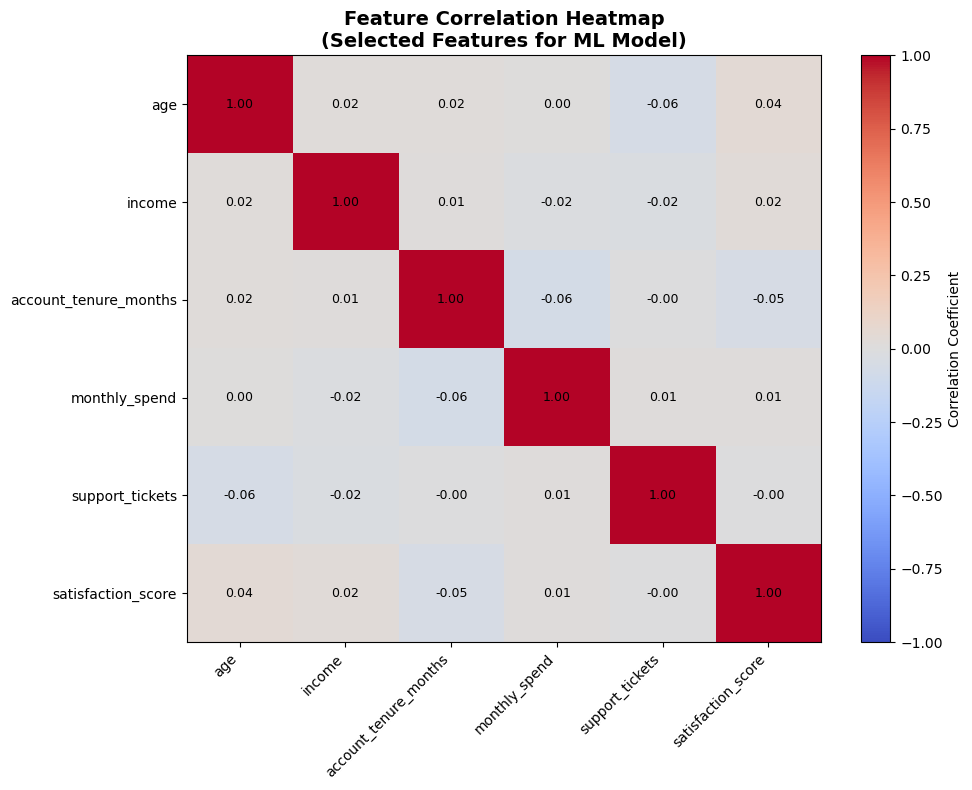

✅ Saved correlation heatmap


In [34]:
# Practical ML Example 3: Train/Validation Split by Conditions
print("=== ML Example 3: Conditional Data Splitting ===\n")

# Create training set: older customers (more established patterns)
# Create validation set: younger customers (different behavior)
train_mask = df_clean['age'] >= 35
val_mask = df_clean['age'] < 35

X_train = df_clean.loc[train_mask, numerical_cols]
y_train = df_clean.loc[train_mask, 'churned']
X_val = df_clean.loc[val_mask, numerical_cols]
y_val = df_clean.loc[val_mask, 'churned']

print(f"Training set (age >= 35): {len(X_train)} samples")
print(f"  Churn rate: {y_train.mean()*100:.1f}%")
print(f"Validation set (age < 35): {len(X_val)} samples")
print(f"  Churn rate: {y_val.mean()*100:.1f}%\n")

# Practical ML Example 4: Correlation Analysis on Selected Features
print("=== ML Example 4: Correlation Heatmap ===\n")

# Select features for correlation analysis
corr_features = ['age', 'income', 'account_tenure_months', 'monthly_spend', 'support_tickets', 'satisfaction_score']
corr_matrix = df_clean.loc[:, corr_features].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(corr_features)), corr_features, rotation=45, ha='right')
plt.yticks(range(len(corr_features)), corr_features)
plt.title('Feature Correlation Heatmap\n(Selected Features for ML Model)', fontsize=14, fontweight='bold')

# Add correlation values as text
for i in range(len(corr_features)):
    for j in range(len(corr_features)):
        text = plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=9)

plt.tight_layout()
plt.show()
print("✅ Saved correlation heatmap")

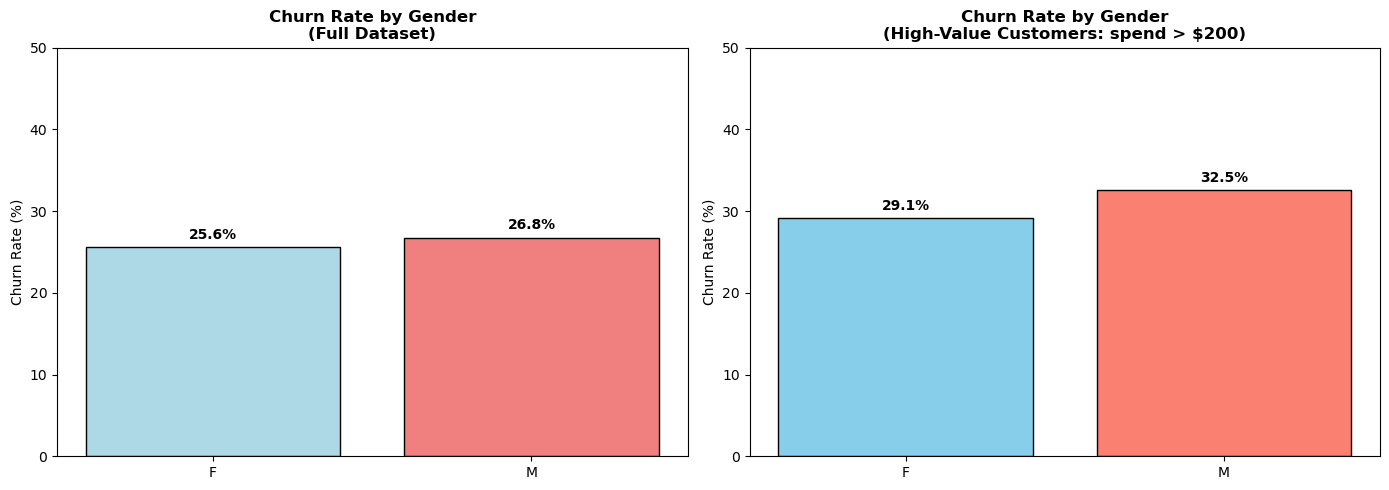

✅ Saved churn comparison by segment


In [35]:
# Visualization: Category comparison after filtering
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn by gender - full dataset
churn_by_gender = df.groupby('gender')['churned'].mean() * 100
axes[0].bar(churn_by_gender.index, churn_by_gender.values, color=['lightblue', 'lightcoral'], edgecolor='black')
axes[0].set_title('Churn Rate by Gender\n(Full Dataset)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 50)
for i, v in enumerate(churn_by_gender.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Churn by gender - high-value customers only
high_value = df.loc[df['monthly_spend'] > 200]
churn_by_gender_hv = high_value.groupby('gender')['churned'].mean() * 100
axes[1].bar(churn_by_gender_hv.index, churn_by_gender_hv.values, color=['skyblue', 'salmon'], edgecolor='black')
axes[1].set_title('Churn Rate by Gender\n(High-Value Customers: spend > $200)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 50)
for i, v in enumerate(churn_by_gender_hv.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print("✅ Saved churn comparison by segment")

## 🛠️ Hands-On Exercises {#exercises}

Complete these exercises to master Pandas indexing and selection. Try each one before checking the solutions!

### Exercise 1: Basic .loc Usage
Select the first 5 rows and only the columns `customer_id`, `age`, and `gender` using `.loc[]`. What is the shape of the result?

In [36]:
# your code here



### Exercise 2: Basic .iloc Usage
Select rows at positions 100-109 (10 rows) and columns at positions 1, 3, 5 (age, income, monthly_spend) using `.iloc[]`. Print the first 3 rows of the result.

In [37]:
# your code here


### Exercise 3: Single Condition Filtering
Filter the DataFrame to show only customers who are 60 years or older. How many customers meet this criteria? What is their average monthly spend?

In [38]:
# your code here


### Exercise 4: Multiple Conditions with AND
Find all female customers (`gender == 'F'`) with an income greater than $70,000. Display their `customer_id`, `age`, `income`, and `churned` status.

In [39]:
# your code here


### Exercise 5: Multiple Conditions with OR
Select customers who have either more than 5 support tickets OR a satisfaction score below 2.0. Count how many are in this group and what percentage churned.

In [40]:
# your code here


### Exercise 6: Combining Selection and Filtering
Create a subset containing only `age`, `income`, and `satisfaction_score` for customers who have not churned (`churned == 0`). What is the average satisfaction score in this subset?

In [41]:
# your code here


### Exercise 7: Using query()
Use the `query()` method to find customers aged between 30 and 50 (inclusive) with a monthly spend between $100 and $200. Return all columns.

In [42]:
# your code here


### Exercise 8: Setting Custom Index
Set `customer_id` as the index of the DataFrame. Then select customer with ID 1500 using `.loc[]` and display their complete information.

In [43]:
# your code here


### Exercise 9: Feature Subset for ML
Create a feature matrix `X` containing only numerical columns (exclude `customer_id` and `churned`) and a target vector `y` containing only the `churned` column. Do this for customers with `account_tenure_months` > 12 only. Print the shapes of X and y.

In [44]:
# your code here


### Exercise 10: Age-Based Filtering
Create three separate DataFrames:
- `young`: customers aged 18-30
- `middle`: customers aged 31-50  
- `senior`: customers aged 51+

Calculate the churn rate for each group and determine which age group has the highest churn rate.

In [45]:
# your code here


### Exercise 11: Preparing Clean Feature Matrix
Create a completely clean dataset for ML:
1. Filter out customers with `income < 0` (if any) or `age < 18`
2. Select only these columns: `age`, `income`, `monthly_spend`, `satisfaction_score`, `account_tenure_months`
3. Create `X_clean` (features) and `y_clean` (target: `churned`)
4. Verify there are no missing values in `X_clean`

Print the final shape and the first 5 rows of X_clean.

In [46]:
# your code here


## Solutions (check after attempting) {#solutions}

### Solution 1: Basic .loc Usage
Select the first 5 rows and only the columns `customer_id`, `age`, and `gender` using `.loc[]`.

In [47]:
# Solution 1
result = df.loc[0:4, ['customer_id', 'age', 'gender']]
print(result)
print(f"Shape: {result.shape}")  # Should be (5, 3)

# Expected output: 5 rows, 3 columns with customer_id, age, gender

   customer_id  age gender
0         1001   56      M
1         1002   69      M
2         1003   46      F
3         1004   32      M
4         1005   60      M
Shape: (5, 3)


### Solution 2: Basic .iloc Usage
Select rows at positions 100-109 and columns at positions 1, 3, 5.

In [48]:
# Solution 2
result = df.iloc[100:110, [1, 3, 5]]
print(result.head(3))
print(f"Shape: {result.shape}")  # Should be (10, 3)

# Expected output: 10 rows with age, income, monthly_spend columns

     age  income  monthly_spend
100   27   50709            205
101   79   40993            217
102   53   66356            126
Shape: (10, 3)


### Solution 3: Single Condition Filtering
Filter customers who are 60 years or older.

In [49]:
# Solution 3
seniors = df.loc[df['age'] >= 60]
count = len(seniors)
avg_spend = seniors['monthly_spend'].mean()
print(f"Customers aged 60+: {count}")
print(f"Average monthly spend: ${avg_spend:.2f}")

# Expected: ~120-130 customers (roughly 12-13% of 1000), avg spend around $150

Customers aged 60+: 344
Average monthly spend: $151.00


### Solution 4: Multiple Conditions with AND
Find female customers with income > $70,000.

In [50]:
# Solution 4
high_earning_females = df.loc[(df['gender'] == 'F') & (df['income'] > 70000), 
                               ['customer_id', 'age', 'income', 'churned']]
print(high_earning_females.head())
print(f"Total found: {len(high_earning_females)}")

# Expected: ~150-200 rows depending on random data generation

    customer_id  age  income  churned
19         1020   20   87771        1
20         1021   39   84603        1
25         1026   47   79917        0
33         1034   39   71357        1
51         1052   72   78561        0
Total found: 148


### Solution 5: Multiple Conditions with OR
Select customers with >5 support tickets OR satisfaction < 2.0.

In [51]:
# Solution 5
at_risk = df.loc[(df['support_tickets'] > 5) | (df['satisfaction_score'] < 2.0)]
count = len(at_risk)
churn_rate = at_risk['churned'].mean() * 100
print(f"At-risk customers: {count}")
print(f"Churn rate in this group: {churn_rate:.1f}%")

# Expected: ~50-100 customers, churn rate likely higher than average 30%

At-risk customers: 122
Churn rate in this group: 32.0%


### Solution 6: Combining Selection and Filtering
Create subset with specific columns for non-churned customers.

In [52]:
# Solution 6
retained = df.loc[df['churned'] == 0, ['age', 'income', 'satisfaction_score']]
avg_sat = retained['satisfaction_score'].mean()
print(f"Retained customers: {len(retained)}")
print(f"Average satisfaction: {avg_sat:.2f}")
print(retained.head())

# Expected: ~700 customers (70% of 1000), avg satisfaction around 5.5

Retained customers: 738
Average satisfaction: 5.42
   age  income  satisfaction_score
0   56   67150                 5.5
1   69   48254                 2.4
2   46   56144                 2.6
3   32   56919                 4.3
4   60   87137                 4.9


### Solution 7: Using query()
Find customers aged 30-50 with monthly spend $100-$200.

In [53]:
# Solution 7
mid_segment = df.query('age >= 30 and age <= 50 and monthly_spend >= 100 and monthly_spend <= 200')
print(f"Mid-segment customers: {len(mid_segment)}")
print(mid_segment[['customer_id', 'age', 'monthly_spend']].head())

# Expected: ~300-400 customers depending on distribution

Mid-segment customers: 144
    customer_id  age  monthly_spend
10         1011   36            117
20         1021   39            134
25         1026   47            149
29         1030   38            116
33         1034   39            182


### Solution 8: Setting Custom Index
Set `customer_id` as index and select customer 1500.

In [54]:
# Solution 8
df_id_index = df.set_index('customer_id')
customer_1500 = df_id_index.loc[1500]
print("Customer 1500 info:")
print(customer_1500)

# Expected: Single row with all columns for customer_id=1500

Customer 1500 info:
age                         64
gender                       F
income                   27783
account_tenure_months       57
monthly_spend              257
support_tickets              0
satisfaction_score         9.3
churned                      1
Name: 1500, dtype: object


### Solution 9: Feature Subset for ML
Create X and y for customers with tenure > 12 months.

In [55]:
# Solution 9
numerical_cols = ['age', 'income', 'account_tenure_months', 'monthly_spend', 
                  'support_tickets', 'satisfaction_score']
mask = df['account_tenure_months'] > 12
X = df.loc[mask, numerical_cols]
y = df.loc[mask, 'churned']
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Features: {X.columns.tolist()}")

# Expected: ~900 rows (90% have tenure > 12 in random 1-120 range), 6 feature columns

X shape: (908, 6)
y shape: (908,)
Features: ['age', 'income', 'account_tenure_months', 'monthly_spend', 'support_tickets', 'satisfaction_score']


### Solution 10: Age-Based Filtering
Create three age groups and compare churn rates.

In [56]:
# Solution 10
young = df.loc[(df['age'] >= 18) & (df['age'] <= 30)]
middle = df.loc[(df['age'] >= 31) & (df['age'] <= 50)]
senior = df.loc[df['age'] >= 51]

young_churn = young['churned'].mean() * 100
middle_churn = middle['churned'].mean() * 100
senior_churn = senior['churned'].mean() * 100

print(f"Young (18-30): {len(young)} customers, churn rate: {young_churn:.1f}%")
print(f"Middle (31-50): {len(middle)} customers, churn rate: {middle_churn:.1f}%")
print(f"Senior (51+): {len(senior)} customers, churn rate: {senior_churn:.1f}%")

highest = max([('Young', young_churn), ('Middle', middle_churn), ('Senior', senior_churn)], key=lambda x: x[1])
print(f"\nHighest churn rate: {highest[0]} group at {highest[1]:.1f}%")

# Expected: Varies by random seed, but typically Middle or Young have slightly higher churn

Young (18-30): 191 customers, churn rate: 24.1%
Middle (31-50): 323 customers, churn rate: 29.4%
Senior (51+): 486 customers, churn rate: 24.9%

Highest churn rate: Middle group at 29.4%


### Solution 11: Preparing Clean Feature Matrix
Create a clean dataset for ML modeling.

In [57]:
# Solution 11
# Step 1: Filter valid customers
valid_mask = (df['income'] > 0) & (df['age'] >= 18)
df_valid = df.loc[valid_mask]

# Step 2: Select feature columns
feature_cols = ['age', 'income', 'monthly_spend', 'satisfaction_score', 'account_tenure_months']
X_clean = df_valid.loc[:, feature_cols]
y_clean = df_valid.loc[:, 'churned']

# Step 3: Verify no missing values
missing_count = X_clean.isnull().sum().sum()

print(f"X_clean shape: {X_clean.shape}")
print(f"y_clean shape: {y_clean.shape}")
print(f"Missing values in X_clean: {missing_count}")
print("\nFirst 5 rows of X_clean:")
print(X_clean.head())

# Expected: (1000, 5) shape for X_clean (all data valid in synthetic dataset), 0 missing values

X_clean shape: (999, 5)
y_clean shape: (999,)
Missing values in X_clean: 0

First 5 rows of X_clean:
   age  income  monthly_spend  satisfaction_score  account_tenure_months
0   56   67150              0                 5.5                     17
1   69   48254            230                 2.4                     88
2   46   56144             95                 2.6                     21
3   32   56919            213                 4.3                     51
4   60   87137             -7                 4.9                     59
